In [162]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [163]:
# A neuron is a computational unit that receives one or more inputs, 
# applies weights to these inputs, sums them up, 
# and then passes the sum through an activation function to produce an output.

import numpy as np

class Neuron:
    """
    A class representing a single neuron in a neural network.

    Attributes:
        activation (function): Activation function to apply to the neuron's output.
        initialization (str): Initialization method for weights ('xavier' or 'he').
        learning_rate_schedule (bool): Whether to apply learning rate scheduling during training.
    """

    def __init__(self, activation, initialization='xavier', learning_rate_schedule=False):
        """
        Initialize the neuron with specified activation function and weight initialization method.

        Args:
            activation (str): Name of the activation function.
            initialization (str, optional): Initialization method for weights. Defaults to 'xavier'.
            learning_rate_schedule (bool, optional): Whether to apply learning rate scheduling during training. Defaults to False.
        """
        self.activation = self._get_activation(activation)
        self.weights = None
        self.bias = None
        self.initialization = initialization
        self.learning_rate_schedule = learning_rate_schedule

    def _get_activation(self, activation):
        """
        Get the activation function based on the provided name.

        Args:
            activation (str): Name of the activation function.

        Returns:
            function: Activation function corresponding to the provided name.

        Raises:
            ValueError: If the provided activation function name is not supported.
        """
        activation_funcs = {
            'linear':self.linear,
            'step': self.step,
            'sigmoid': self.sigmoid,
            'tanh': self.tanh,
            'relu': self.relu,
            'leaky_relu': self.leaky_relu,
            'softmax': self.softmax
        }
        if activation in activation_funcs:
            return activation_funcs[activation]
        else:
            raise ValueError(f"Activation function '{activation}' not supported.")

    def initialize(self, input_size):
        """
        Initialize the weights and bias of the neuron.

        Args:
            input_size (int): Size of the input features.
        """
        if self.initialization == 'xavier':
            self.weights = np.random.randn(input_size) / np.sqrt(input_size)
        elif self.initialization == 'he':
            self.weights = np.random.randn(input_size) * np.sqrt(2 / input_size)
        else:
            raise ValueError(f"Invalid initialization method: {self.initialization}")

        self.bias = np.random.randn()

    def predict(self, X):
        """
        Predict the output of the neuron for input data.

        Args:
            X (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Predicted outputs.
        """
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def fit(self, X, y, initial_learning_rate=0.01, n_iters=1000):
        """
        Train the neuron using gradient descent.

        Args:
            X (numpy.ndarray): Input features.
            y (numpy.ndarray): Target labels.
            initial_learning_rate (float, optional): Initial learning rate. Defaults to 0.01.
            n_iters (int, optional): Number of training iterations. Defaults to 1000.
        """
        n_samples, n_features = X.shape
        self.initialize(n_features)

        # Assuming binary classification
        if np.unique(y).size == 2:
            y_ = np.where(y > 0, 1, 0)
        else:
            y_ = y  # For other types of classification, leave y as it is

        learning_rate = initial_learning_rate
        for epoch in range(1, n_iters + 1):
            y_predicted = self.predict(X)
            errors = y_ - y_predicted

            self.weights += learning_rate * np.dot(X.T, errors)
            self.bias += learning_rate * np.sum(errors)

            if self.learning_rate_schedule:
                learning_rate = initial_learning_rate / np.sqrt(epoch)

    # Activation functions
    @staticmethod
    def linear(x):
        """
        Linear activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying linear function.
        """
        return x
    
    @staticmethod
    def step(x):
        """
        Step activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying step function.
        """
        return np.where(x > 0, 1, 0)

    @staticmethod
    def sigmoid(x):
        """
        Sigmoid activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying sigmoid function.
        """
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def tanh(x):
        """
        Hyperbolic tangent activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying hyperbolic tangent function.
        """
        return np.tanh(x)

    @staticmethod
    def relu(x):
        """
        Rectified Linear Unit (ReLU) activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying ReLU function.
        """
        return np.maximum(0, x)

    @staticmethod
    def leaky_relu(x, alpha=0.01):
        """
        Leaky ReLU activation function.

        Args:
            x (numpy.ndarray): Input data.
            alpha (float, optional): Slope of the negative part. Defaults to 0.01.

        Returns:
            numpy.ndarray: Output after applying Leaky ReLU function.
        """
        return np.where(x > 0, x, alpha * x)

    @staticmethod
    def softmax(x):
        """
        Softmax activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying softmax function.
        """
        exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)


In [164]:
# It takes multiple binary inputs, applies weights to them, sums them up, 
# and then passes the sum through an activation function, 
# typically a step function, to produce a binary output.
#
# Perceptrons are typically used for binary classification tasks and can only learn linear decision boundaries.

class Perceptron:
    """
    A simple perceptron classifier.

    Attributes:
        learning_rate (float): The learning rate for training.
        n_iters (int): The number of iterations for training.
        neuron (Neuron): The neuron instance used for classification.
    """

    def __init__(self, learning_rate=0.01, n_iters=1000):
        """
        Initialize the perceptron.

        Args:
            learning_rate (float, optional): The learning rate for training. Defaults to 0.01.
            n_iters (int, optional): The number of iterations for training. Defaults to 1000.
        """
        self.neuron = Neuron(activation="step")
        self.learning_rate = learning_rate
        self.n_iters = n_iters

    def fit(self, X, y):
        """
        Fit the perceptron to the training data.

        Args:
            X (numpy.ndarray): The input features.
            y (numpy.ndarray): The target labels.
        """
        self.neuron.fit(X, y, self.learning_rate, self.n_iters)

    def predict(self, X):
        """
        Predict the labels for input data.

        Args:
            X (numpy.ndarray): The input features.

        Returns:
            numpy.ndarray: Predicted labels.
        """
        return self.neuron.predict(X)
    
    def get_weights(self):
        """
        Get the weights of the perceptron.

        Returns:
            numpy.ndarray: Weights of the perceptron.
        """
        return self.neuron.weights

    def get_bias(self):
        """
        Get the bias of the perceptron.

        Returns:
            float: Bias of the perceptron.
        """
        return self.neuron.bias


In [165]:
class MLP:
    def __init__(self, input_neurons=1, output_neurons=1, inner_layers=[0], learning_rate=0.01, n_iters=1000):
        self.input_neurons = input_neurons
        self.output_neurons = output_neurons
        self.inner_layers = inner_layers
        self.neurons = self.create_network()
        self.learning_rate = learning_rate
        self.n_iters = n_iters

        if len(inner_layers) < 0:
            raise ValueError("At least two layers are needed for an MLP.")
        
    def create_network(self):
        """
        Create the neural network with the specified architecture.

        Returns:
            list: List of neuron layers.
        """
        neurons = []

        # Input layer
        input_layer = [Neuron() for _ in range(self.input_neurons)]
        neurons.append(input_layer)

        # Inner layers
        for num_neurons in self.inner_layers:
            inner_layer = [Neuron() for _ in range(num_neurons)]
            neurons.append(inner_layer)

        # Output layer
        output_layer = [Neuron() for _ in range(self.output_neurons)]
        neurons.append(output_layer)

        return neurons

    def fit(self, X, y):
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                predicted = self.predict(x_i)
                errors = [y[idx] - predicted[-1]]
                for layer_idx in reversed(range(len(self.layers) - 1)):
                    errors.append(np.dot(errors[-1], self.neurons[layer_idx].weights.T))
                errors.reverse()
                for layer_idx, neuron in enumerate(self.neurons):
                    neuron.fit(X[idx], errors[layer_idx], self.learning_rate)

    def predict(self, X):
        outputs = [X]
        output = X
        for neuron in self.neurons:
            output = neuron.predict(output)
            outputs.append(output)
        return outputs

    def get_weights(self):
        return [neuron.weights for neuron in self.neurons]

    def get_biases(self):
        return [neuron.bias for neuron in self.neurons]


In [166]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

X, y = datasets.make_blobs(
    n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [167]:
p = Perceptron(learning_rate=0.01, n_iters=1000)
p.fit(X_train, y_train)
predictions = p.predict(X_test)

print("Perceptron classification accuracy", accuracy(y_test, predictions))

Perceptron classification accuracy 1.0


In [168]:
def plot_perceptron_decision_boundary(X_train, y_train, p):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train, cmap=plt.cm.coolwarm)

    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])

    x1_1 = (-1 * p.get_weights()[0] * x0_1 - p.get_bias()) / p.get_weights()[1]
    x1_2 = (-1 * p.get_weights()[0] * x0_2 - p.get_bias()) / p.get_weights()[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])

    # Create a grid of points
    xx, yy = np.meshgrid(np.linspace(x0_1, x0_2, 100), np.linspace(ymin - 3, ymax + 3, 100))
    Z = p.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary as a color gradient
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.2)

    plt.show()

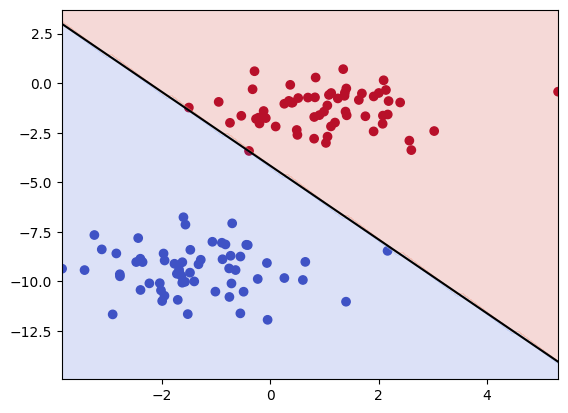

In [169]:
plot_perceptron_decision_boundary(X_train, y_train, p)

In [170]:
mlp = MLP(layers=[2, 4, 1], learning_rate=0.01, n_iters=1000)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(predictions)

ValueError: Activation function '4' not supported.

: 